# Câu hỏi nghiên cứu số 3: Luật kết hợp nào có ý nghĩa kinh doanh cao nhất?

## Xác định luật tốt nhất

### Tiền xử lí dữ liệu

In [38]:
import pandas as pd

df = pd.read_csv("Online Retail.csv", encoding="ISO-8859-1")

# Loại hóa đơn hủy
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Loại số lượng và giá không hợp lệ
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Loại dữ liệu thiếu
df.dropna(subset=['InvoiceNo', 'Description'], inplace=True)

#In ngẫu nhiên 5 dòng bất kì
df.sample(5)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
258575,559660,84576,BLUE CAT BISCUIT BARREL PINK HEART,2,11-07-11 13:19,1.95,16701.0,United Kingdom
334086,566227,21080,SET/20 RED RETROSPOT PAPER NAPKINS,96,11-09-11 10:42,0.72,14258.0,United Kingdom
90123,543985,22154,ANGEL DECORATION 3 BUTTONS,1,15-02-11 9:44,0.83,NaN,United Kingdom
379403,569692,21931,JUMBO STORAGE BAG SUKI,20,05-10-11 15:17,2.08,14389.0,United Kingdom
46704,540357,21876,POTTERING MUG,108,06-01-11 15:14,0.42,13093.0,United Kingdom


In [39]:
# Tổng hóa đơn sau khi tiền xử lí
total_invoices = df['InvoiceNo'].nunique()
print("Tổng số hóa đơn:", total_invoices)


Tổng số hóa đơn: 19960


### Biến đổi dữ liệu sang dạng giao dịch

In [40]:
basket = (
    df.groupby('InvoiceNo')['Description']
    .apply(list)
)
# Thiết lập để không giới hạn độ dài ký tự hiển thị
pd.set_option('display.max_colwidth', None)

# In 5 dòng đầu của giỏ hàng
basket.head()

InvoiceNo
536365                                                                                                                                [WHITE HANGING HEART T-LIGHT HOLDER, WHITE METAL LANTERN, CREAM CUPID HEARTS COAT HANGER, KNITTED UNION FLAG HOT WATER BOTTLE, RED WOOLLY HOTTIE WHITE HEART., SET 7 BABUSHKA NESTING BOXES, GLASS STAR FROSTED T-LIGHT HOLDER]
536366                                                                                                                                                                                                                                                                                                            [HAND WARMER UNION JACK, HAND WARMER RED POLKA DOT]
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE KITCHEN, FELTCRAFT PRINCESS CHARLOTTE DOLL, IVORY KNITTED MUG COSY , BOX OF 6 ASSORTED COLOUR TEASPOONS, BOX OF VINTAGE JIGSAW BLOCKS , BOX OF VINTAGE ALPHABET BLOCKS, HOME BUILDING BLOC

### Chuyển sang ma trận nhị phân

In [41]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)

df_te = pd.DataFrame(te_ary, columns=te.columns_)
df_te.head()


,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [42]:
# Tổng số giao dịch (Mỗi dòng là một hóa đơn)
df_te.shape[0]


19960

In [43]:
# Tính số lượng sản phẩm duy nhất dựa trên cột Description
unique_products_count = df['Description'].nunique()

print(f"Tổng số sản phẩm duy nhất là: {unique_products_count}")

Tổng số sản phẩm duy nhất là: 4026


### Khai phá tập phổ biến
#### Code Apriori: Tập phổ biến được khai phá bằng thuật toán Apriori với ngưỡng hỗ trợ tối thiểu nhằm loại bỏ các kết hợp hiếm, không mang ý nghĩa kinh doanh

In [45]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df_te,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.sort_values(by='support', ascending=False).head()


,support,itemsets
276,0.113026,(WHITE HANGING HEART T-LIGHT HOLDER)
103,0.104659,(JUMBO BAG RED RETROSPOT)
199,0.099599,(REGENCY CAKESTAND 3 TIER)
158,0.084419,(PARTY BUNTING)
128,0.078357,(LUNCH BAG RED RETROSPOT)


### Sinh luật kết hợp

In [46]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules = rules.sort_values(by='lift', ascending=False)
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.038327,0.038427,0.027104,0.707190,18.403524,1.0,0.025631,3.283944,0.983351,0.545913,0.695488,0.706268
159,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(PINK REGENCY TEACUP AND SAUCER),0.038427,0.038327,0.027104,0.705346,18.403524,1.0,0.025631,3.263732,0.983454,0.545913,0.693602,0.706268
161,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.050752,0.029960,0.027104,0.534057,17.825724,1.0,0.025584,2.081887,0.994367,0.505607,0.519667,0.719370
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(GREEN REGENCY TEACUP AND SAUCER),0.029960,0.050752,0.027104,0.904682,17.825724,1.0,0.025584,9.958782,0.973054,0.505607,0.899586,0.719370
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038327,0.050752,0.031663,0.826144,16.278213,1.0,0.029718,5.459963,0.975974,0.551483,0.816849,0.725017


## Thống kê tổng quan về tập luật kết hợp

In [64]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

print("Đã sinh luật, số luật:", len(rules))


Đã sinh luật, số luật: 31


In [65]:
num_rules = len(rules)

overview = {
    "Số luật": num_rules,
    "Support TB": rules['support'].mean(),
    "Confidence TB": rules['confidence'].mean(),
    "Lift TB": rules['lift'].mean(),
    "Lift max": rules['lift'].max()
}

pd.DataFrame.from_dict(overview, orient='index', columns=['Giá trị'])


,Giá trị
Số luật,31.000000
Support TB,0.027726
Confidence TB,0.698768
Lift TB,11.918915
Lift max,18.403524


### Lọc luật có ý nghĩa kinh doanh cao

In [80]:
# Lọc những luật có Lift > 1.2 (có liên quan) 
# VÀ Support > 0.02 (xuất hiện đủ nhiều để đáng đầu tư kinh doanh)
meaningful_rules = rules[(rules['lift'] > 1.2) & (rules['support'] > 0.02)]

# Sắp xếp lại
meaningful_rules = meaningful_rules.sort_values(by='lift', ascending=False)
meaningful_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.038327,0.038427,0.027104,0.707190,18.403524,1.0,0.025631,3.283944,0.983351,0.545913,0.695488,0.706268
159,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(PINK REGENCY TEACUP AND SAUCER),0.038427,0.038327,0.027104,0.705346,18.403524,1.0,0.025631,3.263732,0.983454,0.545913,0.693602,0.706268
161,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.050752,0.029960,0.027104,0.534057,17.825724,1.0,0.025584,2.081887,0.994367,0.505607,0.519667,0.719370
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(GREEN REGENCY TEACUP AND SAUCER),0.029960,0.050752,0.027104,0.904682,17.825724,1.0,0.025584,9.958782,0.973054,0.505607,0.899586,0.719370
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038327,0.050752,0.031663,0.826144,16.278213,1.0,0.029718,5.459963,0.975974,0.551483,0.816849,0.725017
24,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.050752,0.038327,0.031663,0.623889,16.278213,1.0,0.029718,2.556890,0.988749,0.551483,0.608900,0.725017
158,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER)",(ROSES REGENCY TEACUP AND SAUCER ),0.031663,0.053357,0.027104,0.856013,16.043204,1.0,0.025415,6.574490,0.968329,0.467993,0.847897,0.681997
163,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER)",0.053357,0.031663,0.027104,0.507981,16.043204,1.0,0.025415,1.968089,0.990519,0.467993,0.491893,0.681997
23,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.045741,0.037976,0.027355,0.598028,15.747557,1.0,0.025618,2.393264,0.981388,0.485333,0.582161,0.659173
22,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.037976,0.045741,0.027355,0.720317,15.747557,1.0,0.025618,3.411924,0.973466,0.485333,0.706910,0.659173


## Giải thích các chỉ số

In [81]:
rule = business_rules.iloc[0]

A = list(rule['antecedents'])[0]
B = list(rule['consequents'])[0]

A, B


('CHARLOTTE BAG PINK POLKADOT', 'RED RETROSPOT CHARLOTTE BAG')

In [82]:
rule = business_rules.iloc[0]

ants = list(rule['antecedents'])
cons = list(rule['consequents'])

# P(A)
P_A = df_te[ants].all(axis=1).mean()

# P(B) hoặc P(B∧C) nếu nhiều item
P_B = df_te[cons].all(axis=1).mean()

# P(A∩B)
P_A_B = rule['support']

lift_manual = P_A_B / (P_A * P_B)

print("P(A):", P_A)
print("P(B):", P_B)
print("P(A∩B):", P_A_B)
print("Lift tính tay:", lift_manual)




P(A): 0.03717434869739479
P(B): 0.051703406813627256
P(A∩B): 0.026152304609218437
Lift tính tay: 13.606531686830063


In [83]:
ants = list(rule['antecedents'])
cons = list(rule['consequents'])

# P(A ∩ B)
P_A_B = rule['support']

# P(A)
P_A = df_te[ants].all(axis=1).mean()

confidence_manual = P_A_B / P_A
print("Confidence tính tay:", confidence_manual)


Confidence tính tay: 0.7035040431266846


## Ý nghĩa kinh doanh

In [84]:
### Luật có ý nghĩa kinh doanh cao nhất
business_rules = business_rules.sort_values(
    by=['lift', 'confidence'],
    ascending=False
)

business_rules.head(1)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.038327,0.038427,0.027104,0.70719,18.403524,1.0,0.025631,3.283944,0.983351,0.545913,0.695488,0.706268


In [75]:
num_transactions = df_te.shape[0]

business_rules['transaction_count'] = (
    business_rules['support'] * num_transactions
).astype(int)

business_rules[
    ['antecedents', 'consequents', 'support', 'transaction_count']
].head(5)


,antecedents,consequents,support,transaction_count
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.027104,541
159,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(PINK REGENCY TEACUP AND SAUCER),0.027104,541
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(GREEN REGENCY TEACUP AND SAUCER),0.027104,541
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031663,632
158,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER)",(ROSES REGENCY TEACUP AND SAUCER ),0.027104,541


## So sánh các luật khác

In [85]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    df_te,
    min_support=0.02,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

business_rules = rules[
    (rules['confidence'] >= 0.7) &
    (rules['lift'] >= 1)
]
# TOP 10 LUẬT THEO LIFT
top_rules = business_rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=False
).head(10)

top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",0.027104,0.707190,18.403524
159,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(PINK REGENCY TEACUP AND SAUCER),0.027104,0.705346,18.403524
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",(GREEN REGENCY TEACUP AND SAUCER),0.027104,0.904682,17.825724
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031663,0.826144,16.278213
158,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER)",(ROSES REGENCY TEACUP AND SAUCER ),0.027104,0.856013,16.043204
22,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.027355,0.720317,15.747557
166,"(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER )",(GREEN REGENCY TEACUP AND SAUCER),0.020441,0.777143,15.312706
164,"(GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER)",(ROSES REGENCY TEACUP AND SAUCER ),0.020441,0.801572,15.022884
140,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.029960,0.781699,14.650440
29,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.038427,0.720188,14.190472


## Trực quan hóa

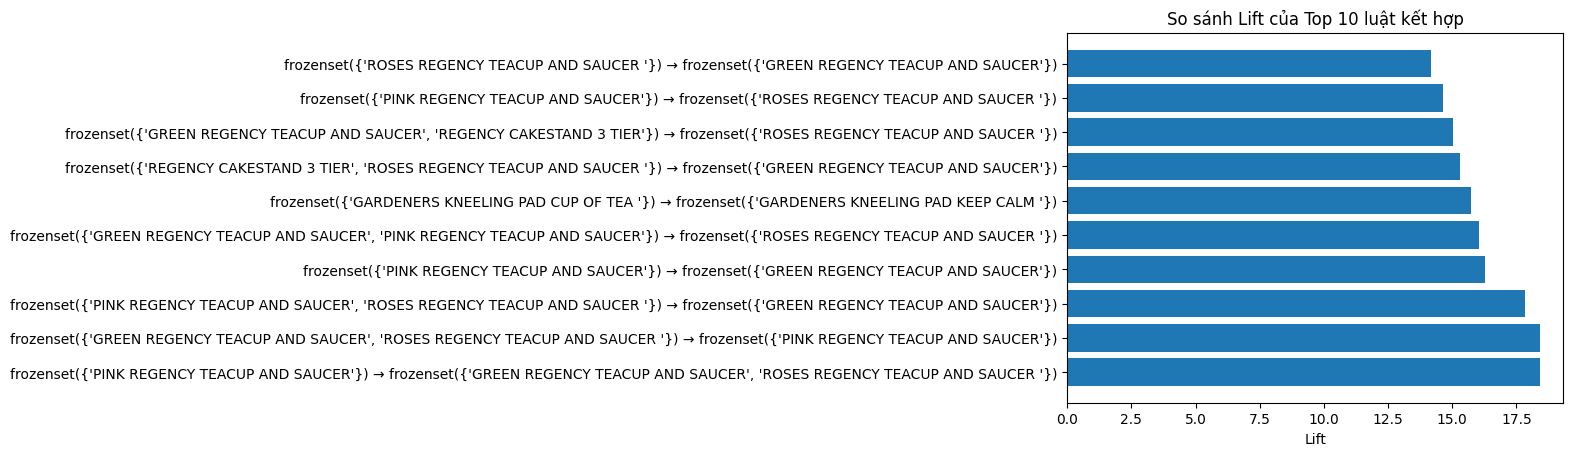

In [79]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(
    range(len(top_rules)),
    top_rules['lift']
)
plt.yticks(
    range(len(top_rules)),
    top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str)
)
plt.xlabel("Lift")
plt.title("So sánh Lift của Top 10 luật kết hợp")
plt.show()
